### **Case 1.B – Anda adalah seorang Data Scientist di suatu perusahaan. Tugas kalian adalah membuat model Artificial Neural Network (ANN) berdasarkan dataset anda:**

membuat model yang dapat menilai harga penjualan mobil bekas pada anak perusahaan dealer otomotif. Harga yang diberikan adalah dalam USD.

In [1]:
import os
import pandas as pd
import numpy as np 
import re
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
import keras
from tensorflow.keras import layers, models
from gc import callbacks

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

In [3]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

The dtype policy mixed_float16 may run slowly because this machine does not have a GPU. Only Nvidia GPUs with compute capability of at least 7.0 run quickly with mixed_float16.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once


In [4]:
import tensorflow as tf

print("TF Version:", tf.__version__)
print("GPU Devices:", tf.config.list_physical_devices('GPU'))
print("CUDA Built:", tf.test.is_built_with_cuda())
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TF Version: 2.12.0
GPU Devices: []
CUDA Built: False
GPU Available: []


In [5]:
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '42'

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

tf.config.experimental.enable_op_determinism()

### **A. Exploratory Data Analysis (EDA)**


In [48]:
BASE_DIR = os.getcwd()
df = pd.read_parquet(os.path.join(BASE_DIR, 'data', '1B.parquet'))

In [49]:
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


Dataset: Berisi fitur-fitur kendaraan mobil dengan Target Selling_Price (regresi)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   object 
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   object 
 6   State or Province  2000 non-null   object 
 7   City               2000 non-null   object 
 8   fuel               2000 non-null   object 
 9   seller_type        2000 non-null   object 
 10  transmission       2000 non-null   object 
 11  owner              2000 non-null   object 
 12  mileage            2000 non-null   object 
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   object 
 16  seats              2000 

Anomaly Detection

In [51]:
df.describe()

,Sales_ID,year,selling_price,km_driven,engine,max_power,seats
count,2000.000000,2000.000000,1998.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,4094.438500,2014.544000,6500.861947,68850.914500,1463.207500,91.872012,5.40800
std,2365.032531,22.593966,8322.011983,50097.963956,500.728476,36.126674,0.94973
min,1.000000,1999.000000,350.000000,0.000000,624.000000,-100.000000,4.00000
25%,2009.500000,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.00000
50%,4070.500000,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.00000
75%,6198.500000,2017.000000,6750.000000,90041.250000,1582.000000,102.000000,5.00000
max,8127.000000,3011.000000,100000.000000,475000.000000,3604.000000,400.000000,14.00000


Melalui describe pada kolom numerik, terlihat adanya anomali max_power dengan angka mines dan juga angka maksimum year yang kemungkinan besar salah pencatatan. km_driven dengan 0 artinya menjual mobil yang belum pernah dipakai.

In [52]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols].describe()

,name,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,torque,sold
count,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,27,5,49,936,4,3,3,5,305,292,2
top,Maruti,Central,California,New York City,Diesel,Individual,Manual,First_Owner,18.9,190Nm@ 2000rpm,N
freq,579,605,222,58,1084,1632,1743,1341,61,128,1489


Diperlukan penanganan string khusus pada torque supaya dapat dipisahkan informasinya. Kolom high cardinality seperti City sudah direpresentasikan oleh State or Province sebenarnya, jadi kita drop saja kolom city supaya encoding tidak meledak.

In [53]:
df.isna().sum()

Sales_ID             0
name                 0
year                 0
selling_price        2
km_driven            0
Region               0
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
torque               0
seats                0
sold                 0
dtype: int64

In [54]:
df = df.drop(columns = ["Sales_ID"], errors = "ignore")

#### **A.1 Handling Null & Invalid Values**

##### A.1.1 Numerical Column

Melihat baris NA pada selling_price, karena hanya 2 kita delete saja

In [55]:
df[df["selling_price"].isnull()]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
702,Maruti,2015,NaN,59292,South,Arkansas,Texarkana,Diesel,Dealer,Manual,First_Owner,28.4,1248,74.00,190Nm@ 2000rpm,5,N
1914,Hyundai,2014,NaN,110000,South,Florida,Davie,Diesel,Individual,Manual,First_Owner,22.54,1396,88.73,219.7Nm@ 1500-2750rpm,5,N


In [56]:
df = df.dropna(subset = ["selling_price"])

In [57]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    display(df[col].value_counts(dropna=False).to_frame().T)

year,2017,2015,2016,2013,2018,2014,2019,2012,2011,2010,...,2007,2006,2005,2020,2004,2003,2000,1999,2002,3011
count,245,211,210,203,189,160,157,150,138,86,...,38,31,19,16,13,8,4,3,2,1


selling_price,5500.00,3000.00,4500.00,6000.00,3500.00,6500.00,4000.00,5000.00,2500.00,7500.00,...,4230.00,520.00,9699.99,5710.00,2279.99,1360.00,5510.00,8100.00,15760.00,11250.00
count,64,63,58,52,44,43,41,41,40,38,...,1,1,1,1,1,1,1,1,1,1


km_driven,70000,120000,80000,60000,50000,90000,100000,40000,30000,110000,...,24857,11533,4000,15732,26235,94385,53473,92500,112879,56800
count,114,114,110,107,89,85,82,76,75,68,...,1,1,1,1,1,1,1,1,1,1


engine,1248,1197,796,1498,998,2179,1396,1199,2494,1198,...,2199,2999,2497,1527,2650,2997,1599,2092,1462,2362
count,236,223,113,112,111,103,77,70,62,58,...,1,1,1,1,1,1,1,1,1,1


max_power,74.00,81.80,88.50,67.00,62.10,68.00,47.30,140.00,67.04,70.00,...,48.21,161.00,80.90,400.00,57.00,121.00,100.57,135.10,117.60,164.70
count,95,58,48,47,45,44,40,40,38,37,...,1,1,1,1,1,1,1,1,1,1


seats,5,7,8,4,6,9,10,14
count,1582,283,55,34,22,17,4,1


Terdapat masalah kolom numerik:
- Year: 3011 sebesar 1 baris saja -> drop
- Max_power negative value

In [58]:
df = df[df["year"] != 3011]

In [59]:
df[df["seats"] > 8].head(5)

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
144,Mahindra,2013,5000.0,70000,Central,Texas,Bryan,Diesel,Individual,Manual,First_Owner,15.96,2523,63.0,180Nm@ 1440-1500rpm,9,Y
260,Tata,2010,2350.0,50000,East,Ohio,Toledo,Diesel,Individual,Manual,First_Owner,10.71,1948,90.0,190Nm@ 2000-3000rpm,14,N
326,Tata,2010,2350.0,90000,Central,Illinois,Elmhurst,Diesel,Individual,Manual,First_Owner,14.0,1948,90.0,190Nm@ 2000-3000,9,N
445,Tata,2008,2000.0,80000,Central,Michigan,Lansing,Diesel,Individual,Manual,First_Owner,12.2,1948,68.0,"115@ 2,500(kgm@ rpm)",10,N
588,Mahindra,2014,9990.0,25000,South,Georgia,Kennesaw,Diesel,Individual,Manual,First_Owner,15.4,2179,120.0,280Nm@ 1800-2800rpm,9,N


In [60]:
df.describe()

,year,selling_price,km_driven,engine,max_power,seats
count,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,2014.045068,6501.112754,68834.630946,1463.482223,91.887579,5.408613
std,3.680770,8324.088841,50126.674047,501.043719,36.150825,0.950312
min,1999.000000,350.000000,0.000000,624.000000,-100.000000,4.000000
25%,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.000000
50%,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.000000
75%,2017.000000,6750.000000,90000.000000,1582.000000,102.000000,5.000000
max,2020.000000,100000.000000,475000.000000,3604.000000,400.000000,14.000000


In [61]:
df[df["km_driven"] == 0]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
647,Mahindra,2018,5500.0,0,East,New Jersey,Trenton,Petrol,Individual,Manual,First_Owner,nan,1198,82.0,115Nm@ 3500-3600rpm,6,N
846,Tata,2012,3000.0,0,Central,Kansas,Prairie Village,Diesel,Individual,Manual,First_Owner,nan,1396,69.0,140Nm@ 1800-3000rpm,5,N


In [62]:
df[df["max_power"] <= 0]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
1061,Maruti,2012,1850.0,60000,Central,Michigan,Bay City,Petrol,Individual,Manual,Second_Owner,19.7,796,-100.0,62Nm@ 3000rpm,5,Y


In [63]:
df = df[df["max_power"] >= 0]

**Fixed Version:**

In [64]:
df.describe()

,year,selling_price,km_driven,engine,max_power,seats
count,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000
mean,2014.046092,6503.442971,68839.057114,1463.816633,91.983715,5.408818
std,3.681408,8325.523295,50138.845207,500.946313,35.903641,0.950506
min,1999.000000,350.000000,0.000000,624.000000,32.800000,4.000000
25%,2012.000000,2750.000000,30000.000000,1197.000000,68.050000,5.000000
50%,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.000000
75%,2017.000000,6750.000000,90041.250000,1582.000000,102.000000,5.000000
max,2020.000000,100000.000000,475000.000000,3604.000000,400.000000,14.000000


In [65]:
for col in num_cols:
    display(df[col].value_counts(dropna=False).to_frame().T)

year,2017,2015,2016,2013,2018,2014,2019,2012,2011,2010,...,2008,2007,2006,2005,2020,2004,2003,2000,1999,2002
count,245,211,210,203,189,160,157,149,138,86,...,54,38,31,19,16,13,8,4,3,2


selling_price,5500.00,3000.00,4500.00,6000.00,3500.00,6500.00,4000.00,5000.00,2500.00,7500.00,...,4230.00,520.00,9699.99,5710.00,2279.99,1360.00,5510.00,8100.00,15760.00,11250.00
count,64,63,58,51,44,43,41,41,40,38,...,1,1,1,1,1,1,1,1,1,1


km_driven,70000,120000,80000,60000,50000,90000,100000,40000,30000,110000,...,24857,11533,4000,15732,26235,94385,53473,92500,112879,56800
count,114,114,110,106,89,85,82,76,75,68,...,1,1,1,1,1,1,1,1,1,1


engine,1248,1197,1498,796,998,2179,1396,1199,2494,1198,...,2199,2999,2497,1527,2650,2997,1599,2092,1462,2362
count,236,222,112,112,111,103,77,70,62,58,...,1,1,1,1,1,1,1,1,1,1


max_power,74.00,81.80,88.50,67.00,62.10,68.00,47.30,140.00,67.04,70.00,...,400.00,158.80,48.21,138.00,121.40,194.30,127.00,189.30,188.00,164.70
count,95,57,48,47,45,44,40,40,38,37,...,1,1,1,1,1,1,1,1,1,1


seats,5,7,8,4,6,9,10,14
count,1580,283,55,34,22,17,4,1


In [66]:
num_cols = df.select_dtypes(include=np.number).columns

##### **A.1.2 Categorical Category**

In [67]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    display(df[col].value_counts(dropna=False).to_frame().T)

name,Maruti,Hyundai,Mahindra,Tata,Toyota,Ford,Honda,Renault,Chevrolet,Volkswagen,...,Lexus,Fiat,Jeep,Audi,Isuzu,Force,Mitsubishi,Land,Daewoo,MG
count,576,360,184,184,122,115,114,54,49,45,...,10,8,7,7,3,2,1,1,1,1


Region,Central,West,East,South,N/A
count,604,507,482,401,2


State or Province,California,Texas,New York,Illinois,Florida,Michigan,Washington,Ohio,Pennsylvania,Indiana,...,Kentucky,Nevada,Nebraska,New Hampshire,Rhode Island,West Virginia,South Dakota,North Dakota,Delaware,Wyoming
count,222,135,123,119,107,82,79,74,65,60,...,13,12,10,10,8,8,7,7,5,2


City,New York City,Los Angeles,Seattle,Chicago,Boston,Washington,Philadelphia,Houston,Miami,Charlotte,...,Highland,Belvidere,Salinas,Aloha,Wylie,Bellevue,Redondo Beach,Fort Lee,Euclid,Walker
count,57,43,25,20,18,17,15,14,13,11,...,1,1,1,1,1,1,1,1,1,1


fuel,Diesel,Petrol,CNG,LPG
count,1082,894,11,9


...

transmission,Manual,Automatic,
count,1740,254,2


owner,First_Owner,Second_Owner,Third_Owner,Fourth_Above_Owner,Test_Drive_Car
count,1338,487,118,51,2


mileage,18.9,18.6,19.7,21.1,17.0,17.8,22.0,15.1,16.1,16.8,...,12.9,14.23,17.42,15.64,15.74,13.73,17.67,10.9,15.26,12.1
count,61,46,37,35,35,31,30,30,29,29,...,1,1,1,1,1,1,1,1,1,1


torque,190Nm@ 2000rpm,200Nm@ 1750rpm,90Nm@ 3500rpm,113Nm@ 4200rpm,114Nm@ 4000rpm,160Nm@ 2000rpm,69Nm@ 3500rpm,330Nm@ 1600-2800rpm,62Nm@ 3000rpm,59Nm@ 2500rpm,...,110Nm@ 4000rpm,240Nm@ 1750rpm,142Nm@ 4000rpm,174Nm@ 4300rpm,350Nm@ 1500-3500rpm,96 Nm at 3000 rpm,113Nm@ 3300rpm,100Nm@ 2700rpm,224nm@ 1500-2750rpm,224Nm@ 4000rpm
count,127,110,101,57,42,41,40,39,36,31,...,1,1,1,1,1,1,1,1,1,1


sold,N,Y
count,1487,509


In [68]:
df[cat_cols].nunique()

name                  27
Region                 5
State or Province     49
City                 935
fuel                   4
seller_type            3
transmission           3
owner                  5
mileage              305
torque               292
sold                   2
dtype: int64

Terdapat beberapa anomali pada kolom kategorikal:
- mileage yang berbentuk angka float terdeteksi sebagai string -> cast type menjadi float numeric column
- City terlalu high cardinality dan sudah di represent oleh State or Province -> drop city
- torque memerlukan pemisahan format dan ekstraksi informasi
- Kolom transmission & region memiliki value kosong atau N/A -> jadikan str unknown

In [69]:
df['mileage'].value_counts(dropna=False).to_frame().T

mileage,18.9,18.6,19.7,21.1,17.0,17.8,22.0,15.1,16.1,16.8,...,12.9,14.23,17.42,15.64,15.74,13.73,17.67,10.9,15.26,12.1
count,61,46,37,35,35,31,30,30,29,29,...,1,1,1,1,1,1,1,1,1,1


In [70]:
df['mileage'] = df['mileage'].replace('Unknown', np.nan)
display(df['mileage'].isna().sum())
df['mileage'] = df['mileage'].astype(str).str.replace(',', '.')
df['mileage'] = df['mileage'].astype(np.float64)
df['mileage'] = df['mileage'].fillna(df['mileage'].median())


np.int64(0)

In [71]:
df = df[df["transmission"].isin(["Automatic", "Manual"])]

In [75]:
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

In [76]:
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])
df = df.drop(columns = ["City"], errors = "ignore")

**Fixed Version**

In [78]:
cat_cols = df.select_dtypes(include=['object']).columns

In [79]:
df[cat_cols].describe()

,name,Region,State or Province,fuel,seller_type,transmission,owner,torque,sold,brand
count,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994
unique,27,5,49,4,3,2,5,292,2,27
top,Maruti,Central,California,Diesel,Individual,Manual,First_Owner,190Nm@ 2000rpm,N,Maruti
freq,574,604,222,1082,1628,1740,1337,127,1486,574


In [80]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000
mean,2014.044634,6507.057257,68875.505517,19.430802,1464.285858,92.016146,5.408225
std,3.681297,8328.850225,50143.206236,3.961438,500.938175,35.904540,0.950270
min,1999.000000,350.000000,0.000000,0.000000,624.000000,32.800000,4.000000
25%,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000
50%,2015.000000,4500.000000,60000.000000,19.330000,1248.000000,82.000000,5.000000
75%,2017.000000,6750.000000,90123.750000,22.320000,1582.000000,102.000000,5.000000
max,2020.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000


#### **A.1.3 Check for Duplication**

In [81]:
df.duplicated().sum()
df[df.duplicated(keep=False)].head(5)


,name,year,selling_price,km_driven,Region,State or Province,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold,brand
180,Skoda,2016,6450.0,11000,Central,Illinois,Petrol,Dealer,Automatic,First_Owner,14.30,1598,103.5,153Nm@ 3800rpm,5,N,Skoda
274,Honda,2016,5500.0,56494,East,New York,Petrol,Trustmark_Dealer,Manual,First_Owner,18.20,1199,88.7,110Nm@ 4800rpm,5,Y,Honda
312,Skoda,2016,6450.0,11000,Central,Illinois,Petrol,Dealer,Automatic,First_Owner,14.30,1598,103.5,153Nm@ 3800rpm,5,N,Skoda
340,BMW,2019,55000.0,8500,Central,Texas,Diesel,Dealer,Automatic,First_Owner,16.78,1995,190.0,400Nm@ 1750-2500rpm,5,N,BMW
346,Volvo,2019,38000.0,20000,East,Pennsylvania,Diesel,Individual,Automatic,First_Owner,18.00,1969,190.0,400Nm,5,N,Volvo


Drop Duplicates dan keep yang pertama saja

In [82]:
df = df.drop_duplicates(keep="first")

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1977 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1977 non-null   object 
 1   year               1977 non-null   int64  
 2   selling_price      1977 non-null   float64
 3   km_driven          1977 non-null   int64  
 4   Region             1977 non-null   object 
 5   State or Province  1977 non-null   object 
 6   fuel               1977 non-null   object 
 7   seller_type        1977 non-null   object 
 8   transmission       1977 non-null   object 
 9   owner              1977 non-null   object 
 10  mileage            1977 non-null   float64
 11  engine             1977 non-null   int64  
 12  max_power          1977 non-null   float64
 13  torque             1977 non-null   object 
 14  seats              1977 non-null   int64  
 15  sold               1977 non-null   object 
 16  brand              1977 non-n

In [84]:
df["torque"].head(10)

0          114Nm@ 4000rpm
1          330Nm@ 1800rpm
2          110Nm@ 4800rpm
3          200Nm@ 1750rpm
4          115Nm@ 4000rpm
5          360Nm@ 2000rpm
6    145@ 4,100(kgm@ rpm)
7          112Nm@ 4000rpm
8          200Nm@ 1750rpm
9           72Nm@ 4386rpm
Name: torque, dtype: object

In [85]:
display(df["torque"].value_counts(dropna=False).to_frame().T)

torque,190Nm@ 2000rpm,200Nm@ 1750rpm,90Nm@ 3500rpm,113Nm@ 4200rpm,114Nm@ 4000rpm,160Nm@ 2000rpm,69Nm@ 3500rpm,330Nm@ 1600-2800rpm,62Nm@ 3000rpm,59Nm@ 2500rpm,...,110Nm@ 4000rpm,240Nm@ 1750rpm,142Nm@ 4000rpm,174Nm@ 4300rpm,350Nm@ 1500-3500rpm,96 Nm at 3000 rpm,113Nm@ 3300rpm,100Nm@ 2700rpm,224nm@ 1500-2750rpm,224Nm@ 4000rpm
count,127,110,101,57,42,41,40,39,35,31,...,1,1,1,1,1,1,1,1,1,1


Pada kolom torque kita dapat memisahkan angka berdasarkan '@' dan untuk kolom dengan rentang, kita hitung menggunakan mean.

In [86]:
def process_torque(text):

    if pd.isna(text) or text == "":
        return None, None
    
    try:
        torque_search = re.findall(r'(\d+\.?\d*)', text)
        if not torque_search:
            return None, None
        torque_val = float(torque_search[0])
        
        parts = text.split('@')
        rpm_part = parts[-1] if len(parts) > 1 else text
        rpm_numbers = re.findall(r'(\d+)', rpm_part)
        
        if not rpm_numbers:
            return torque_val, None
            
        if len(rpm_numbers) >= 2:
            rpm_val = (float(rpm_numbers[0]) + float(rpm_numbers[1])) / 2
        else:
            rpm_val = float(rpm_numbers[0])
            
        return torque_val, rpm_val
    except:
        return None, None

df[['torque_nm', 'rpm_val']] = df['torque'].apply(lambda x: pd.Series(process_torque(x)))
df = df.drop(columns = 'torque')

In [107]:
cat_cols = cat_cols.drop('torque', errors = "ignore")

In [87]:
display(df["torque_nm"].value_counts(dropna=False).to_frame().T)

torque_nm,200.0,190.0,90.0,113.0,114.0,160.0,330.0,320.0,69.0,400.0,...,6.0,35.7,420.7,187.0,136.3,155.0,174.0,277.5,11.0,171.6
count,162,150,101,66,62,52,41,41,40,37,...,1,1,1,1,1,1,1,1,1,1


In [88]:
display(df["rpm_val"].value_counts(dropna=False).to_frame().T)

rpm_val,2000.0,4000.0,3500.0,1750.0,2125.0,NaN,3000.0,2500.0,4200.0,2200.0,...,1548.0,3275.0,877.5,3300.0,1700.0,1740.0,252.0,1090.0,3700.0,2800.0
count,241,230,183,139,128,109,84,82,77,67,...,1,1,1,1,1,1,1,1,1,1


#### **A.1.4 Data Pre-Processing**

In [89]:
df.isna().sum()

name                   0
year                   0
selling_price          0
km_driven              0
Region                 0
State or Province      0
fuel                   0
seller_type            0
transmission           0
owner                  0
mileage                0
engine                 0
max_power              0
seats                  0
sold                   0
brand                  0
torque_nm              0
rpm_val              109
dtype: int64

<Axes: xlabel='rpm_val', ylabel='Count'>

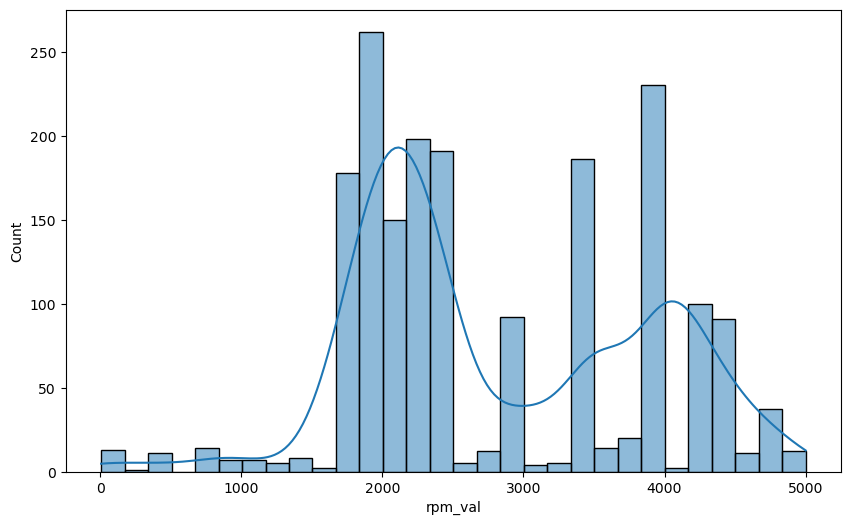

In [90]:
plt.figure(figsize=(10, 6))
sns.histplot(df["rpm_val"].dropna(), bins=30, kde=True)

Impute dengan median saja + Feature Scaling Proper

In [91]:
df["rpm_val"] = df["rpm_val"].fillna(df["rpm_val"].median())

<Axes: xlabel='rpm_val', ylabel='Count'>

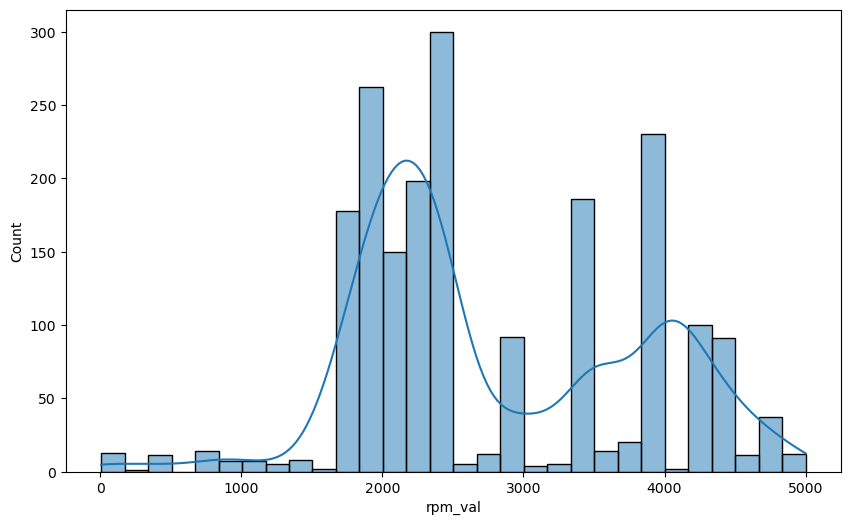

In [92]:
plt.figure(figsize=(10, 6))
sns.histplot(df["rpm_val"].dropna(), bins=30, kde=True)

**Final Dataframe Version**

In [105]:
df[cat_cols].describe()

,name,Region,State or Province,fuel,seller_type,transmission,owner,sold,brand
count,1977,1977,1977,1977,1977,1977,1977,1977,1977
unique,27,5,49,4,3,2,5,2,27
top,Maruti,Central,California,Diesel,Individual,Manual,First_Owner,N,Maruti
freq,574,598,221,1076,1625,1735,1321,1473,574


In [108]:
display(df[num_cols].describe())

display(f"Null: {df.isna().sum().sum()}, Duplicates: {df.duplicated().sum()}")

,year,selling_price,km_driven,engine,max_power,seats
count,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000,1977.000000
mean,2014.019727,6368.084052,69113.106222,1460.903389,91.610797,5.409712
std,3.682093,7989.221368,49993.517443,499.996067,35.515103,0.952339
min,1999.000000,350.000000,0.000000,624.000000,32.800000,4.000000
25%,2012.000000,2750.000000,31000.000000,1197.000000,68.050000,5.000000
50%,2015.000000,4500.000000,60000.000000,1248.000000,82.000000,5.000000
75%,2017.000000,6750.000000,91182.000000,1582.000000,102.000000,5.000000
max,2020.000000,100000.000000,475000.000000,3604.000000,400.000000,14.000000


'Null: 0, Duplicates: 0'

#### **A.1.5 Train Validation Test Splitting** (70/10/20)

In [46]:
target = "selling_price"
X = df.drop(columns=[target])
y = df[target]

print(X.shape[0])

1977


In [ ]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [48]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.3333, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Testing set: {len(X_test)} samples")

Training set: 1383 samples
Validation set: 198 samples
Testing set: 396 samples


<Axes: xlabel='selling_price', ylabel='Count'>

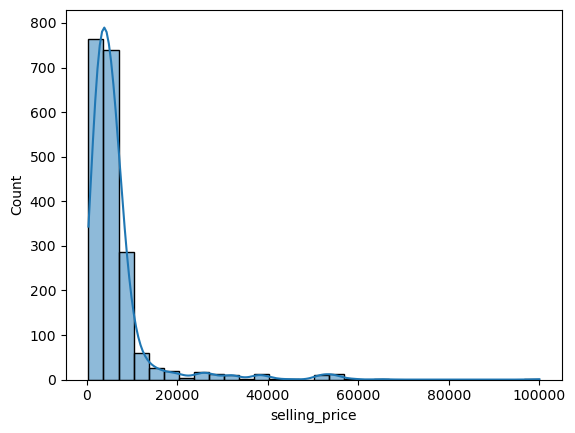

In [49]:
sns.histplot(df[target], bins=30, kde=True)

### **B. Buat Baseline Model.**

- Semua hidden layer wajib menggunakan activation function bernama ReLU dan memiliki jumlah neuron 
minimal 2 kali lipat dari dimensi input data. 

- Model anda harus memiliki minimal 2 hidden layer. 

- Lakukan training pada model tersebut dengan minimal 20 epoch dan jelaskan hasilnya secara singkat.

In [50]:
df[cat_cols].describe()

,name,Region,State or Province,fuel,seller_type,transmission,owner,torque,sold,brand
count,1977,1977,1977,1977,1977,1977,1977,1977,1977,1977
unique,27,5,49,4,3,2,5,292,2,27
top,Maruti,Central,California,Diesel,Individual,Manual,First_Owner,190Nm@ 2000rpm,N,Maruti
freq,574,598,221,1076,1625,1735,1321,127,1473,574


In [ ]:
scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_num = scaler.fit_transform(X_train[num_cols])
X_val_num = scaler.transform(X_val[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_val_cat = ohe.transform(X_val[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

X_train_scaled = np.hstack([X_train_num, X_train_cat])
X_val_scaled = np.hstack([X_val_num, X_val_cat])
X_test_scaled = np.hstack([X_test_num, X_test_cat])

y_train_log =np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

input_dim = X_train_scaled.shape[1]
min_neurons = input_dim * 2

In [52]:
def build_baseline_model(input_dim, neurons):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(neurons, activation = 'relu'),
        layers.Dense(neurons, activation = 'relu'),
        layers.Dense(1)
    ])

    model.compile(
        optimizer='adam', 
        loss='mse', 
        metrics=['mae', tf.keras.metrics.R2Score(name='r2_score')])
    return model

baseline_model = build_baseline_model(input_dim, min_neurons)

history = baseline_model.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs = 30, #min 20 epoch
    batch_size=32,
    verbose=1
)

Upper_Bound_Log = np.log1p(max(max(y_train), max(y_test), max(y_val)))

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 7.5718 - mae: 1.9385 - r2_score: -10.8050 - val_loss: 0.7396 - val_mae: 0.7038 - val_r2_score: -0.1500
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4035 - mae: 0.4392 - r2_score: 0.3709 - val_loss: 0.3269 - val_mae: 0.4707 - val_r2_score: 0.4917
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1510 - mae: 0.2702 - r2_score: 0.7646 - val_loss: 0.1667 - val_mae: 0.3202 - val_r2_score: 0.7408
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0863 - mae: 0.2071 - r2_score: 0.8655 - val_loss: 0.1177 - val_mae: 0.2652 - val_r2_score: 0.8170
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0576 - mae: 0.1728 - r2_score: 0.9102 - val_loss: 0.1039 - val_mae: 0.2502 - val_r2_score: 0.8384
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0420 - mae: 0.1488 - r2_score: 0.9345 - val_loss: 0.0938 - val_mae: 0.2386 - val_r2_score: 0.8541
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 18

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24452\23205759.py:32: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()
C:\Users\Alvin\AppData\Local\Temp\ipykernel_24452\23205759.py:44: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


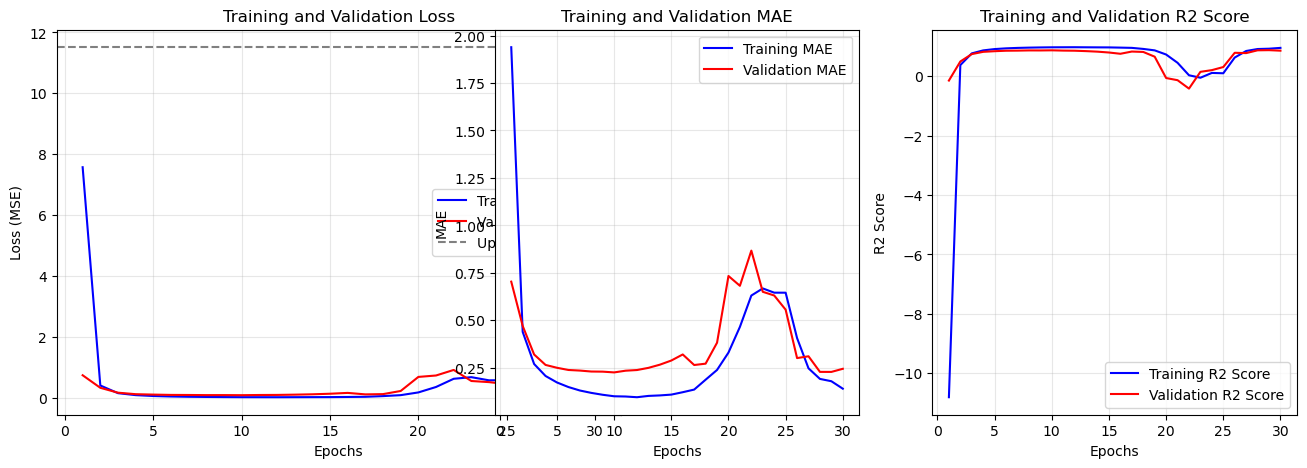

In [53]:
def plot_training_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    mae = history.history['mae']
    val_mae = history.history['val_mae']

    r2 = history.history.get('r2_score', [None] * len(loss))
    r2_val = history.history.get('val_r2_score', [None] * len(loss))
    
    epochs = range(1, len(loss) + 1)


    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')   
    plt.axhline(Upper_Bound_Log, color='gray', linestyle='--', label='Upper Bound (Log)')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha = 0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, mae, 'b-', label='Training MAE')
    plt.plot(epochs, val_mae, 'r-', label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, r2, 'b-', label='Training R2 Score')
    plt.plot(epochs, r2_val, 'r-', label='Validation R2 Score')
    plt.title('Training and Validation R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [54]:
y_pred_log = baseline_model.predict(X_test_scaled).flatten()
y_pred_log = np.clip(y_pred_log, 0, Upper_Bound_Log)
y_pred = np.expm1(y_pred_log)

print("R-squared Score:", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Absolute Percentage Error (MAPE):", mean_absolute_percentage_error(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
R-squared Score: 0.9131741292698841
Mean Squared Error (MSE): 5715980.972817697
Mean Absolute Error (MAE): 1287.7369721871275
Mean Absolute Percentage Error (MAPE): 0.22500616431504114


### **C. Modify Model**
Anda dapat mengubah jumlah neuron dan layer ataupun activation function dari hidden layer. Anda juga dapat melakukan hyperparameter fine-tuning pada model anda. Lakukan training pada modifikasi model anda dan

Jelaskan alasan modifikasi yang anda lakukan.

Modified ver.:
- Menggunakan callbacks dengan kombinasi early stopping dan reduceLrOnPlateu
- Berguna untuk stop jika model sudah tidak belajar lagi
- Ketika proses belajar stagnan, kurangi learning rate secara adaptif

In [ ]:
def build_modified_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        
        layers.Dense(32, activation='relu'),
        layers.Dense(1)])
    
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum = 0.9)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae', tf.keras.metrics.R2Score(name='r2_score')])
    return model

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=20,          
        restore_best_weights=True 
    ),
    
   
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.4,            
        patience=16            
    )
]

modified_model = build_modified_model(input_dim)
history_mod = modified_model.fit(
    X_train_scaled, y_train_log,
    validation_data = (X_val_scaled, y_val_log),
    epochs = 150,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.6698 - mae: 2.0436 - r2_score: -14.0760 - val_loss: 0.3785 - val_mae: 0.5014 - val_r2_score: 0.4114 - learning_rate: 0.0100
Epoch 2/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2966 - mae: 0.4161 - r2_score: 0.5375 - val_loss: 0.2221 - val_mae: 0.3887 - val_r2_score: 0.6546 - learning_rate: 0.0100
Epoch 3/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1876 - mae: 0.3358 - r2_score: 0.7074 - val_loss: 0.1698 - val_mae: 0.3360 - val_r2_score: 0.7360 - learning_rate: 0.0100
Epoch 4/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1761 - mae: 0.3241 - r2_score: 0.7255 - val_loss: 0.1656 - val_mae: 0.3274 - val_r2_score: 0.7425 - learning_rate: 0.0100
Epoch 5/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1715 - mae: 0.3137 - r2_score: 0.7326 - val_loss: 0.1551 - val_mae: 0.3185 - val_r2_score: 0.7589 - learning_rate: 0.0100
Epoch 6/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1631 - mae: 0.3047 - 

C:\Users\Alvin\AppData\Local\Temp\ipykernel_24452\23205759.py:32: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()
C:\Users\Alvin\AppData\Local\Temp\ipykernel_24452\23205759.py:44: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


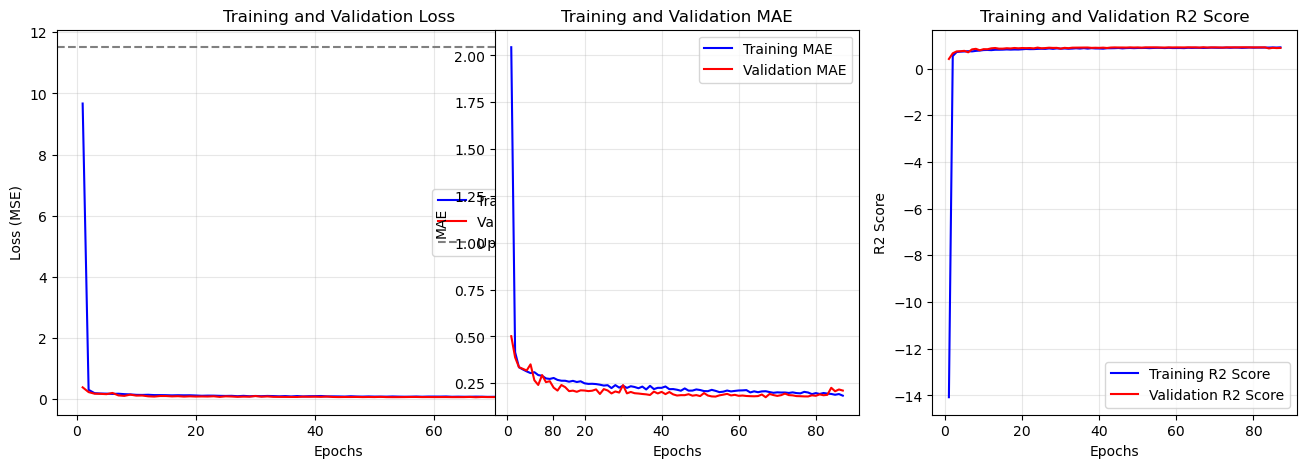

In [75]:
plot_training_history(history_mod)

Pada model modifikasi, Pemilihan optimizer SGD (Stochastic Gradient Descent) dengan momentum.

Meskipun Adam lebih cepat dalam konvergensi, SGD memberikan kemampuan generalisasi (Generalization Gap) yang lebih kecil antara data Training dan Validation. 

SGD memperbarui bobot berdasarkan gradien yang lebih "berisik" (noisy) dibandingkan Adam yang lebih halus. Noise ini bertindak sebagai bentuk regularisasi alami dan juga sangat membantu dalam menghindari overfitting (hafal data training).

Hal ini krusial pada dataset harga mobil bekas untuk memastikan model tidak mengalami overfitting pada varians harga yang sangat spesifik dan dapat memprediksi data uji dengan lebih stabil.

In [76]:
y_pred_log = modified_model.predict(X_test_scaled).flatten()
y_pred_log = np.clip(y_pred_log, 0, Upper_Bound_Log)
y_pred = np.expm1(y_pred_log)

print("R-squared Score:", r2_score(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Absolute Percentage Error (MAPE):", mean_absolute_percentage_error(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
R-squared Score: 0.9390352482660006
Mean Squared Error (MSE): 4013473.8413078263
Mean Absolute Error (MAE): 1029.5666809432564
Mean Absolute Percentage Error (MAPE): 0.1822235358314481


### **D. Evaluation & Summary**

In [77]:
summary = pd.DataFrame({
    "Model": ["Baseline", "Modified"],
    "R-squared": [r2_score(y_test, np.expm1(baseline_model.predict(X_test_scaled).flatten())), r2_score(y_test, y_pred)],
    "MSE": [mean_squared_error(y_test, np.expm1(baseline_model.predict(X_test_scaled).flatten())), mean_squared_error(y_test, y_pred)],
    "MAE": [mean_absolute_error(y_test, np.expm1(baseline_model.predict(X_test_scaled).flatten())), mean_absolute_error(y_test, y_pred)],
    "MAPE": [mean_absolute_percentage_error(y_test, np.expm1(baseline_model.predict(X_test_scaled).flatten())), mean_absolute_percentage_error(y_test, y_pred)]
})

summary.T

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,0,1
Model,Baseline,Modified
R-squared,0.913174,0.939035
MSE,5715980.865502,4013473.841308
MAE,1287.736962,1029.566681
MAPE,0.225006,0.182224


**Performa Model Modified:**
- Model ANN yang dimodifikasi menunjukan peningatkan performa signifikan dibandingkan dengan model baseline. Penurunan nilai kesalahan (error metrics) dan peningkatan kecocokan model

1. R2 tetap terjaga di kisaran 93~94% sehingga model berhasil menjelaskan variansi harga dengan sangat baik.
2. MAPE turun dari 22.50% ke 18.22% yang artinya rata-rata kesalahan presentase prediksi model terhadap harga aktual berkurang.
3. MAE turun dari 1287.73 menjadi 1029.56, secara rata-rata selisih prediksi model terhadap harga pasar mobil bekas adalah sekitar $1029.56

Model dengan MAPE di angka 18% menunjukan model sudah cukup layar digunakan oleh anak perusahaan dealer otomotif sebagai alat bantu yang menentukan kisaran harga jual mobil bekas secara objektif.